In [4]:
import pandas as pd

df = pd.read_csv("../data/viral_social_media_trends.csv")

# Create Engagement Score
df['Engagement_Score'] = df['Likes'] + df['Shares'] + df['Comments']

# Sort by Engagement
top_posts = df.sort_values(by='Engagement_Score', ascending=False)

print(top_posts.head(10))


        Post_ID   Platform     Hashtag Content_Type     Region    Views  \
2907  Post_2908  Instagram  #Challenge  Live Stream         UK  4498056   
4960  Post_4961  Instagram       #Tech        Tweet    Germany  2964544   
3619  Post_3620    YouTube      #Dance         Reel    Germany  3371356   
1871  Post_1872  Instagram       #Tech       Shorts      India   301575   
556    Post_557  Instagram    #Fitness         Post    Germany   129205   
2864  Post_2865  Instagram      #Viral         Reel  Australia  1831119   
4759  Post_4760    YouTube      #Music        Tweet      India  2050005   
2492  Post_2493    Twitter    #Fashion         Reel     Brazil  3802774   
3016  Post_3017    Twitter    #Fashion        Tweet         UK  1072473   
8        Post_9    Twitter  #Education  Live Stream      India  2169523   

       Likes  Shares  Comments Engagement_Level  Engagement_Score  
2907  491674   95872     47593             High            635139  
4960  487730   97256     45944        

In [5]:
# Group by Hashtag and calculate average engagement
hashtag_engagement = df.groupby('Hashtag')['Engagement_Score'].mean()

# Sort hashtags by average engagement
top_hashtags = hashtag_engagement.sort_values(ascending=False)

print(top_hashtags.head(10))


Hashtag
#Education    336857.047619
#Tech         334433.908350
#Fitness      328845.938433
#Dance        328607.891129
#Comedy       327832.681188
#Viral        325169.896050
#Fashion      325133.845996
#Music        324002.941176
#Gaming       319512.645094
#Challenge    317602.717949
Name: Engagement_Score, dtype: float64


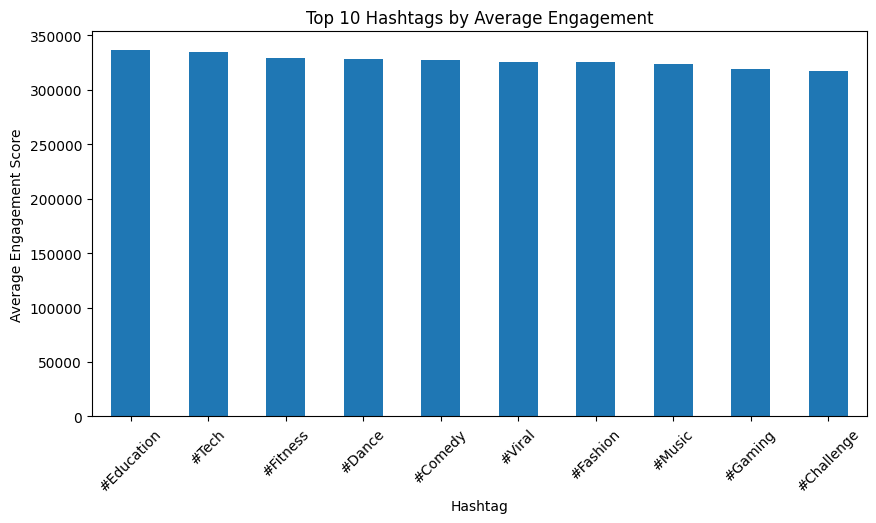

In [3]:
import matplotlib.pyplot as plt

# Take top 10 hashtags
top_10 = top_hashtags.head(10)

plt.figure(figsize=(10,5))
top_10.plot(kind='bar')
plt.title("Top 10 Hashtags by Average Engagement")
plt.ylabel("Average Engagement Score")
plt.xticks(rotation=45)
plt.show()


In [2]:
import pandas as pd

df = pd.read_csv("../data/viral_social_media_trends.csv")

df['Engagement_Score'] = df['Likes'] + df['Shares'] + df['Comments']

hashtag_engagement = df.groupby('Hashtag')['Engagement_Score'].mean()

top_hashtags = hashtag_engagement.sort_values(ascending=False)


In [4]:
# Detect High Engagement Posts (Spike Detection)

threshold = df['Engagement_Score'].mean() + df['Engagement_Score'].std()

df['Spike'] = df['Engagement_Score'] > threshold

print(df[df['Spike'] == True].head(10))


    Post_ID   Platform     Hashtag Content_Type     Region    Views   Likes  \
8    Post_9    Twitter  #Education  Live Stream      India  2169523  496078   
11  Post_12    Twitter      #Music         Reel  Australia  4585669  465871   
23  Post_24    Twitter  #Education       Shorts      Japan  4357851  449803   
24  Post_25    YouTube      #Dance        Tweet    Germany   731492  474649   
38  Post_39     TikTok     #Gaming       Shorts        USA  4499253  469481   
49  Post_50  Instagram    #Fashion         Reel      Japan  2747788  422463   
52  Post_53    YouTube     #Comedy        Tweet      Japan  1357850  472399   
54  Post_55    Twitter      #Dance         Reel        USA  4006009  491965   
55  Post_56    YouTube    #Fitness        Tweet  Australia  3934991  389693   
58  Post_59    YouTube  #Challenge         Post    Germany  2291491  474568   

    Shares  Comments Engagement_Level  Engagement_Score  Spike  
8    96041     30174           Medium            622293   True  


In [5]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Load pre-trained embedding model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Get unique hashtags
hashtags = df['Hashtag'].unique()

print("Total hashtags:", len(hashtags))
print(hashtags[:10])


c:\Users\ashle\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\ashle\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ashle\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to ru

Total hashtags: 10
<StringArray>
['#Challenge', '#Education',     '#Dance',    '#Comedy',    '#Gaming',
     '#Music',     '#Viral',   '#Fitness',      '#Tech',   '#Fashion']
Length: 10, dtype: str


In [6]:
# Convert hashtags into embeddings
embeddings = model.encode(hashtags)

print("Embedding shape:", embeddings.shape)


Embedding shape: (10, 384)


In [7]:
# Calculate similarity matrix
similarity_matrix = cosine_similarity(embeddings)

print("Similarity Matrix Shape:", similarity_matrix.shape)
print(similarity_matrix)


Similarity Matrix Shape: (10, 10)
[[1.0000004  0.54207313 0.4947669  0.509789   0.5265106  0.5059246
  0.48251405 0.51932305 0.546226   0.4785    ]
 [0.54207313 0.9999998  0.5522147  0.5617708  0.57692754 0.5767041
  0.50904393 0.5023128  0.6552931  0.5235953 ]
 [0.4947669  0.5522147  1.         0.54087096 0.54520845 0.6595726
  0.45099533 0.6040813  0.52048063 0.5351882 ]
 [0.509789   0.5617708  0.54087096 1.         0.5676708  0.5323154
  0.5233217  0.44513717 0.5156206  0.5027001 ]
 [0.5265106  0.57692754 0.54520845 0.5676708  1.         0.60904276
  0.5012269  0.4937436  0.55242723 0.4712826 ]
 [0.5059246  0.5767041  0.6595726  0.5323154  0.60904276 0.9999999
  0.49707657 0.52542967 0.54494524 0.5380093 ]
 [0.48251405 0.50904393 0.45099533 0.5233217  0.5012269  0.49707657
  0.99999994 0.4509884  0.4541522  0.49415612]
 [0.51932305 0.5023128  0.6040813  0.44513717 0.4937436  0.52542967
  0.4509884  1.0000004  0.5429907  0.5183458 ]
 [0.546226   0.6552931  0.52048063 0.5156206  0.552

In [8]:
# Find similar hashtag pairs
threshold = 0.6  # similarity above this means strongly related

for i in range(len(hashtags)):
    for j in range(i + 1, len(hashtags)):
        if similarity_matrix[i][j] > threshold:
            print(f"{hashtags[i]}  <-->  {hashtags[j]}  |  Score: {similarity_matrix[i][j]:.2f}")


#Education  <-->  #Tech  |  Score: 0.66
#Dance  <-->  #Music  |  Score: 0.66
#Dance  <-->  #Fitness  |  Score: 0.60
#Gaming  <-->  #Music  |  Score: 0.61


In [9]:
from sklearn.cluster import KMeans

# Choose number of clusters (you can change 3 to 4 if needed)
num_clusters = 3

kmeans = KMeans(n_clusters=num_clusters, random_state=42)
clusters = kmeans.fit_predict(embeddings)

# Create cluster mapping
for i in range(num_clusters):
    print(f"\nCluster {i+1}:")
    for j in range(len(hashtags)):
        if clusters[j] == i:
            print(" -", hashtags[j])



Cluster 1:
 - #Comedy
 - #Viral

Cluster 2:
 - #Dance
 - #Fitness

Cluster 3:
 - #Challenge
 - #Education
 - #Gaming
 - #Music
 - #Tech
 - #Fashion


In [10]:
# Create cluster dataframe
cluster_df = pd.DataFrame({
    'Hashtag': hashtags,
    'Cluster': clusters
})

# Merge cluster info with main dataset
df = df.merge(cluster_df, on='Hashtag')

print(df.head())


  Post_ID   Platform     Hashtag Content_Type     Region    Views   Likes  \
0  Post_1     TikTok  #Challenge        Video         UK  4163464  339431   
1  Post_2  Instagram  #Education       Shorts      India  4155940  215240   
2  Post_3    Twitter  #Challenge        Video     Brazil  3666211  327143   
3  Post_4    YouTube  #Education       Shorts  Australia   917951  127125   
4  Post_5     TikTok      #Dance         Post     Brazil    64866  171361   

   Shares  Comments Engagement_Level  Engagement_Score  Spike  Cluster  
0   53135     19346             High            411912  False        2  
1   65860     27239           Medium            308339  False        2  
2   39423     36223           Medium            402789  False        2  
3   11687     36806              Low            175618  False        2  
4   69581      6376           Medium            247318  False        1  


In [11]:
# Check average engagement per AI cluster
cluster_performance = df.groupby('Cluster')['Engagement_Score'].mean()

print(cluster_performance)


Cluster
0    326533.695740
1    328731.528101
2    326358.741449
Name: Engagement_Score, dtype: float64


In [12]:
# Step 1: Calculate Z-score for Engagement
df['Engagement_Z'] = (
    (df['Engagement_Score'] - df['Engagement_Score'].mean()) 
    / df['Engagement_Score'].std()
)

# Mark advanced spikes (Z-score > 2)
df['Advanced_Spike'] = df['Engagement_Z'] > 2

# See top spikes
print(df[df['Advanced_Spike'] == True].head())


        Post_ID   Platform     Hashtag Content_Type     Region    Views  \
556    Post_557  Instagram    #Fitness         Post    Germany   129205   
1871  Post_1872  Instagram       #Tech       Shorts      India   301575   
2492  Post_2493    Twitter    #Fashion         Reel     Brazil  3802774   
2864  Post_2865  Instagram      #Viral         Reel  Australia  1831119   
2907  Post_2908  Instagram  #Challenge  Live Stream         UK  4498056   

       Likes  Shares  Comments Engagement_Level  Engagement_Score  Spike  \
556   493844   93705     39629             High            627178   True   
1871  492868   95534     42034             High            630436   True   
2492  499236   96550     28438           Medium            624224   True   
2864  491782   86681     48075             High            626538   True   
2907  491674   95872     47593             High            635139   True   

      Cluster  Engagement_Z  Advanced_Spike  
556         1      2.027788            True  


In [13]:
from sklearn.metrics import silhouette_score

score = silhouette_score(embeddings, clusters)

print("Silhouette Score:", score)


Silhouette Score: 0.021482612937688828


In [14]:
# Use all unique hashtags instead of just top 10
all_hashtags = df['Hashtag'].unique()

# Create embeddings for all hashtags
all_embeddings = model.encode(all_hashtags)

# Cluster again
kmeans_all = KMeans(n_clusters=3, random_state=42)
all_clusters = kmeans_all.fit_predict(all_embeddings)

# Check silhouette score again
score_all = silhouette_score(all_embeddings, all_clusters)

print("New Silhouette Score:", score_all)


New Silhouette Score: 0.021482612937688828


In [15]:
# Add semantic context to hashtags
contextual_hashtags = [
    f"This is a viral social media trend about {tag.replace('#','')}"
    for tag in df['Hashtag'].unique()
]

# Create embeddings again with context
context_embeddings = model.encode(contextual_hashtags)

# Cluster again
kmeans_context = KMeans(n_clusters=3, random_state=42)
context_clusters = kmeans_context.fit_predict(context_embeddings)

# Check silhouette score
context_score = silhouette_score(context_embeddings, context_clusters)

print("Context-based Silhouette Score:", context_score)


Context-based Silhouette Score: 0.05162929370999336


In [16]:
# Attach context-based clusters back to dataframe
cluster_map = pd.DataFrame({
    'Hashtag': df['Hashtag'].unique(),
    'Cluster': context_clusters
})

df = df.merge(cluster_map, on='Hashtag', how='left')

# Count advanced spikes per cluster
cluster_spike_analysis = df.groupby('Cluster')['Advanced_Spike'].sum()

print(cluster_spike_analysis)


KeyError: 'Cluster'

In [17]:
print(df.columns)


Index(['Post_ID', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views',
       'Likes', 'Shares', 'Comments', 'Engagement_Level', 'Engagement_Score',
       'Spike', 'Cluster_x', 'Engagement_Z', 'Advanced_Spike', 'Cluster_y'],
      dtype='str')


In [18]:
cluster_spike_analysis = df.groupby('Cluster_y')['Advanced_Spike'].sum()

print(cluster_spike_analysis)


Cluster_y
0    0
1    7
2    1
Name: Advanced_Spike, dtype: int64


In [19]:
# See hashtags inside each cluster
for cluster in df['Cluster_y'].unique():
    print(f"\nCluster {cluster}:")
    print(df[df['Cluster_y'] == cluster]['Hashtag'].unique())



Cluster 2:
<StringArray>
['#Challenge']
Length: 1, dtype: str

Cluster 1:
<StringArray>
['#Education',     '#Dance',    '#Gaming',     '#Music',     '#Viral',
   '#Fitness',      '#Tech',   '#Fashion']
Length: 8, dtype: str

Cluster 0:
<StringArray>
['#Comedy']
Length: 1, dtype: str


In [20]:
# Create final research summary table

final_summary = df.groupby('Cluster_y').agg({
    'Engagement_Score': 'mean',
    'Advanced_Spike': 'sum'
}).reset_index()

final_summary.columns = ['Cluster', 'Average_Engagement', 'Spike_Count']

print(final_summary)


   Cluster  Average_Engagement  Spike_Count
0        0       327832.681188            0
1        1       327942.539117            7
2        2       317602.717949            1


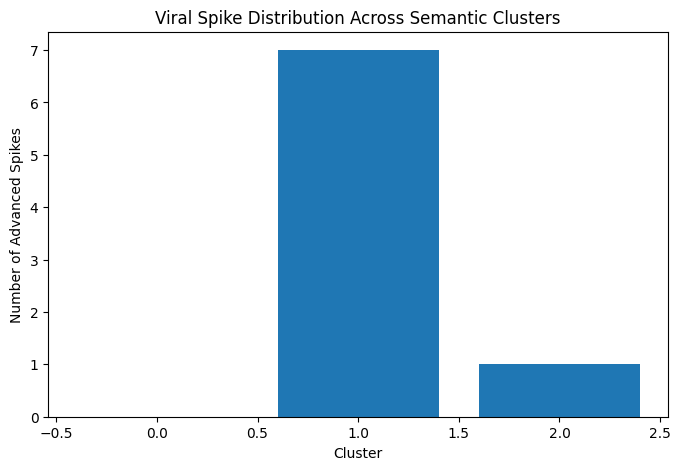

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(final_summary['Cluster'], final_summary['Spike_Count'])
plt.title("Viral Spike Distribution Across Semantic Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Advanced Spikes")
plt.show()


In [22]:
# Keep only final cluster column
df_clean = df.drop(columns=['Cluster_x'])

# Rename Cluster_y to Cluster
df_clean = df_clean.rename(columns={'Cluster_y': 'Cluster'})

print(df_clean.head())


  Post_ID   Platform     Hashtag Content_Type     Region    Views   Likes  \
0  Post_1     TikTok  #Challenge        Video         UK  4163464  339431   
1  Post_2  Instagram  #Education       Shorts      India  4155940  215240   
2  Post_3    Twitter  #Challenge        Video     Brazil  3666211  327143   
3  Post_4    YouTube  #Education       Shorts  Australia   917951  127125   
4  Post_5     TikTok      #Dance         Post     Brazil    64866  171361   

   Shares  Comments Engagement_Level  Engagement_Score  Spike  Engagement_Z  \
0   53135     19346             High            411912  False      0.574171   
1   65860     27239           Medium            308339  False     -0.125221   
2   39423     36223           Medium            402789  False      0.512567   
3   11687     36806              Low            175618  False     -1.021440   
4   69581      6376           Medium            247318  False     -0.537275   

   Advanced_Spike  Cluster  
0           False        2  
1   

In [23]:
# Export cleaned final dataset
df_clean.to_csv("../data/final_ai_trend_analysis.csv", index=False)

print("Final dataset exported successfully.")


Final dataset exported successfully.


In [24]:
final_summary.to_csv("../data/final_cluster_summary.csv", index=False)

print("Cluster summary exported successfully.")


Cluster summary exported successfully.


In [25]:
# Platform-level spike analysis
platform_spike_analysis = df.groupby('Platform')['Advanced_Spike'].sum().reset_index()

print(platform_spike_analysis)


    Platform  Advanced_Spike
0  Instagram               5
1     TikTok               0
2    Twitter               1
3    YouTube               2


In [26]:
# Count total posts per platform
platform_total_posts = df.groupby('Platform')['Post_ID'].count().reset_index()
platform_total_posts.columns = ['Platform', 'Total_Posts']

# Merge with spike counts
platform_analysis = platform_total_posts.merge(
    platform_spike_analysis,
    on='Platform'
)

# Calculate spike rate
platform_analysis['Spike_Rate'] = (
    platform_analysis['Advanced_Spike'] / platform_analysis['Total_Posts']
)

print(platform_analysis)


    Platform  Total_Posts  Advanced_Spike  Spike_Rate
0  Instagram         1212               5    0.004125
1     TikTok         1260               0    0.000000
2    Twitter         1204               1    0.000831
3    YouTube         1324               2    0.001511


In [27]:
from scipy.stats import chi2_contingency

# Create contingency table
contingency = pd.crosstab(df['Platform'], df['Advanced_Spike'])

print(contingency)

# Perform Chi-Square Test
chi2, p, dof, expected = chi2_contingency(contingency)

print("\nChi-square value:", chi2)
print("p-value:", p)


Advanced_Spike  False  True 
Platform                    
Instagram        1207      5
TikTok           1260      0
Twitter          1203      1
YouTube          1322      2

Chi-square value: 7.310932195623973
p-value: 0.06262068806834814


In [28]:
# Final Master Summary

master_summary = {
    "Total_Viral_Spikes": df['Advanced_Spike'].sum(),
    "Dominant_Cluster": final_summary.loc[final_summary['Spike_Count'].idxmax(), 'Cluster'],
    "Max_Cluster_Spikes": final_summary['Spike_Count'].max(),
    "Chi_Square_Value": chi2,
    "Chi_Square_p_value": p
}

print(master_summary)


{'Total_Viral_Spikes': np.int64(8), 'Dominant_Cluster': np.int32(1), 'Max_Cluster_Spikes': np.int64(7), 'Chi_Square_Value': np.float64(7.310932195623973), 'Chi_Square_p_value': np.float64(0.06262068806834814)}
